# IPLACEX

## Basic Analysis

In [27]:
import pandas as pd

# Try reading the CSV file and check the columns
df = pd.read_csv('data/temp/chats_delta.csv', sep=',', on_bad_lines='skip', header=0, encoding='utf-8-sig')

# Count the number of unique session_ids (chats)
chats = df['session_id'].nunique()
print(f"Number of chats: {chats}")

# Count the number of unique messages
messages = df['message_id'].nunique()
print(f"Number of messages: {messages}")

# Average number of messages per session
avg_messages = messages / chats
print(f"Average messages per session: {avg_messages:.2f}")

# Identify sessions that contain administrative messages
chats_admin = df[df['administrativa'] == 1]['session_id'].unique()
print(f"\nNumber of chats with administrative messages: {len(chats_admin)}")
# Percentage of chats with administrative messages
print(f"Percentage of chats with administrative messages: {len(chats_admin) / chats * 100:.2f}%")

# Remove sessions that contain administrative messages
df_edu = df[~df['session_id'].isin(chats_admin)]

# Update statistics with the filtered dataset
chats_edu = df_edu['session_id'].nunique()
print("\nStatistics after removing chats with administrative messages:")
print(f"Number of educational chats: {chats_edu}")

messages_edu = df_edu['message_id'].nunique()
print(f"Number of educational messages: {messages_edu}")

avg_messages_edu = messages_edu / chats_edu
print(f"Average messages per session: {avg_messages_edu:.2f}")

# Check df_edu with sessions with number of messages > 1
df_edu = df_edu[df_edu['session_id'].isin(df_edu['session_id'].value_counts()[df_edu['session_id'].value_counts() > 1].index)]
print(f"\n\nNumber educational chats with more than 1 message: {df_edu['session_id'].nunique()}")

# Percentage of chats with more than 1 message
print(f"Percentage of chats with more than 1 message: {df_edu['session_id'].nunique() / chats_edu * 100:.2f}%")


# Percent od educational chats
print(f"\n\nPercentage of total educational chats: {df_edu['session_id'].nunique() / chats * 100:.2f}%")

# Save the filtered dataset to a new CSV file
df_edu.to_csv('data/temp/chats_edu_utf8.csv', sep=',', index=False, encoding='utf-8')
print(f"Filtered dataset saved to 'data/temp/chats_edu_utf8.csv'")



Number of chats: 7906
Number of messages: 11059
Average messages per session: 1.40

Number of chats with administrative messages: 4116
Percentage of chats with administrative messages: 52.06%

Statistics after removing chats with administrative messages:
Number of educational chats: 3790
Number of educational messages: 5441
Average messages per session: 1.44


Number educational chats with more than 1 message: 1473
Percentage of chats with more than 1 message: 38.87%


Percentage of total educational chats: 18.63%
Filtered dataset saved to 'data/temp/chats_edu_utf8.csv'
Filtered dataset saved to 'data/temp/chats_edu_utf8.csv'


## Analysis of School

In [28]:
messages_per_session = df_edu.groupby('session_id').size().reset_index(name='num_messages')

chat_sizes = df_edu[['session_id', 'ESCUELA']].drop_duplicates()
chat_sizes = chat_sizes.merge(messages_per_session, on='session_id')

course_stats = chat_sizes.groupby('ESCUELA').agg({
    'num_messages': ['mean', 'max', 'count']
}).round(2)

# Rename columns for better readability
course_stats.columns = ['Average Messages', 'Max Messages', 'Number of chats']

courses = course_stats.head(100)
# order by number of chats
courses = courses.sort_values(by='Number of chats', ascending=False)
display(courses)

# Order by average messages
courses = courses.sort_values(by='Average Messages', ascending=False)
display(courses)

# Export the table ordered by average messages to CSV
courses.to_csv('data/temp/school_stats.csv')
print('\nTabela exportada para: data/temp/school_stats.csv')




,Average Messages,Max Messages,Number of chats
ESCUELA,,,
ESCUELA DE TECNOLOGÍA,3.13,15,310
ESCUELA DE EDUCACIÓN,3.04,20,294
ESCUELA DE INFORMÁTICA Y TELECOMUNICACIONES,3.45,24,221
ESCUELA DE CONSTRUCCIÓN,3.81,36,158
ESCUELA DE DESARROLLO SOCIAL Y SERVICIO PÚBLICO,3.12,28,155
ESCUELA DE ADMINISTRACIÓN Y NEGOCIOS,3.55,50,155
ESCUELA DE SALUD,3.86,15,111
ESCUELA DE GASTRONOMÍA,4.26,14,27


,Average Messages,Max Messages,Number of chats
ESCUELA,,,
ESCUELA DE GASTRONOMÍA,4.26,14,27
ESCUELA DE SALUD,3.86,15,111
ESCUELA DE CONSTRUCCIÓN,3.81,36,158
ESCUELA DE ADMINISTRACIÓN Y NEGOCIOS,3.55,50,155
ESCUELA DE INFORMÁTICA Y TELECOMUNICACIONES,3.45,24,221
ESCUELA DE TECNOLOGÍA,3.13,15,310
ESCUELA DE DESARROLLO SOCIAL Y SERVICIO PÚBLICO,3.12,28,155
ESCUELA DE EDUCACIÓN,3.04,20,294



Tabela exportada para: data/temp/school_stats.csv


In [29]:
# Agrupamento de cursos em áreas
area_map = {
    'Escuela de Gastronomía': 'Health Sciences',
    'Escuela de Salud': 'Health Sciences',
    'Escuela de Construcción': 'Engineering and Technology',
    'Escuela de Tecnología': 'Engineering and Technology',
    'Escuela de Informática y Telecomunicaciones': 'Engineering and Technology',
    'Escuela de Desarrollo Social y Servicio Público': 'Social Sciences and Humanities',
    'Escuela de Educación': 'Social Sciences and Humanities',
    'Escuela de Administración y Negocios': 'Business and Administration'
}


# Read the filtered dataset again
df_edu = pd.read_csv('data/temp/chats_edu_utf8.csv', sep=',', on_bad_lines='skip', header=0, encoding='utf-8-sig')

# Add a new column for the area
# Ajustar keys do dicionário para maiúsculas e mapear
area_map_upper = {k.upper(): v for k, v in area_map.items()}
df_edu['area'] = df_edu['ESCUELA'].map(area_map_upper)

# Group by  session_id
grouped = df_edu.groupby(['session_id', 'area']).size().reset_index(name='num_messages')
grouped = grouped.groupby('area').agg({
    'num_messages': ['mean', 'max', 'count']
}).round(2)
# Rename columns for better readability
grouped.columns = ['Average Messages', 'Max Messages', 'Number of chats']
# Order by Number of chats
grouped = grouped.sort_values(by='Average Messages', ascending=False)
# Display the grouped data
display(grouped)

# Export the table ordered by average messages to CSV
grouped.to_csv('data/temp/area_stats.csv')
print('\nTabela exportada para: data/temp/area_stats.csv')



,Average Messages,Max Messages,Number of chats
area,,,
Health Sciences,3.93,15,138
Business and Administration,3.55,50,155
Engineering and Technology,3.39,36,689
Social Sciences and Humanities,3.07,28,449



Tabela exportada para: data/temp/area_stats.csv


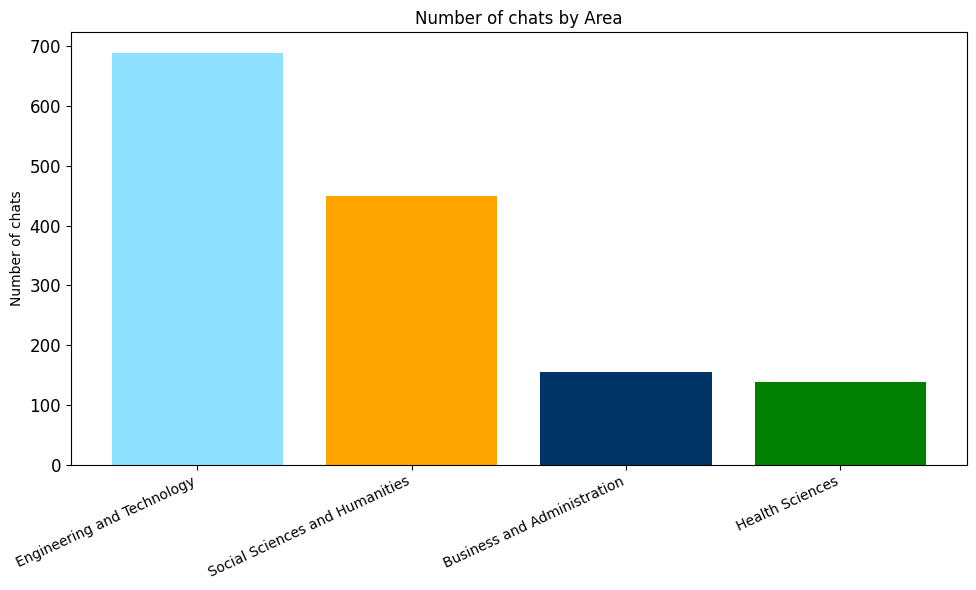

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the filtered dataset again
df = pd.read_csv('data/temp/area_stats.csv')

# Define colors for each area
area_cores = {
    'Health Sciences': '#008000',
    'Engineering and Technology': '#8EE0FF',
    'Social Sciences and Humanities': '#FFA500',
    'Business and Administration': '#003366'
}

# Ordering the DataFrame by 'Number of chats' in descending order
df_sorted = df.sort_values(by='Number of chats', ascending=False)

def get_area_color(area):
    return area_cores.get(area, '#7f7f7f')
colors = [get_area_color(area) for area in df_sorted['area']]

plt.figure(figsize=(10,6))
plt.bar(df_sorted['area'], df_sorted['Number of chats'], color=colors)
plt.xlabel('', fontsize=14)
plt.ylabel('Number of chats', fontsize=10)
plt.title('Number of chats by Area', fontsize=12)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

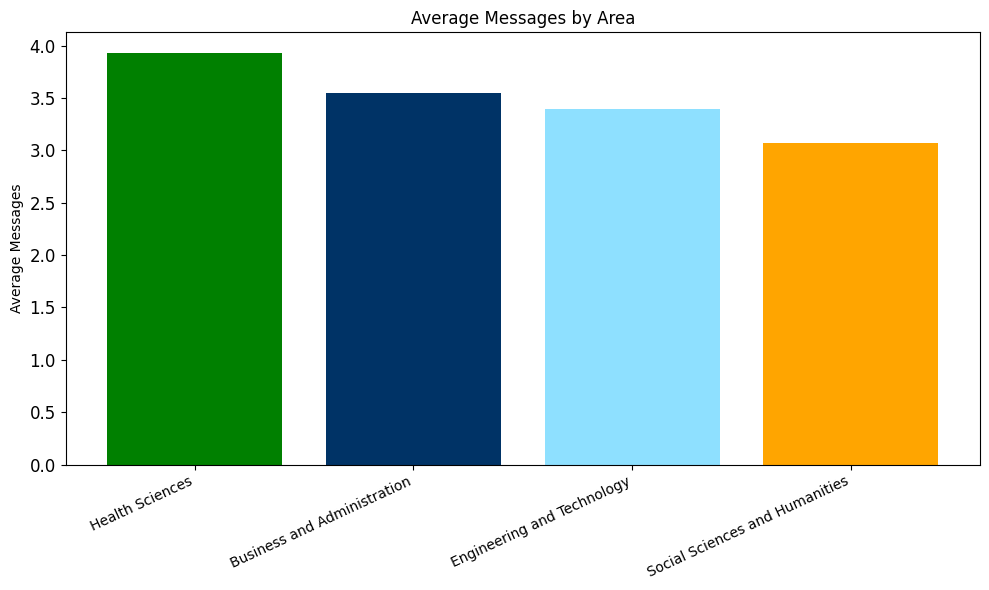

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the filtered dataset again
df = pd.read_csv('data/temp/area_stats.csv')

# Define colors for each area
area_cores = {
    'Health Sciences': '#008000',
    'Engineering and Technology': '#8EE0FF',
    'Social Sciences and Humanities': '#FFA500',
    'Business and Administration': '#003366'
}

# Ordering the DataFrame by 'Number of chats' in descending order
df_sorted = df.sort_values(by='Average Messages', ascending=False)

# Generate a list of colors based on the area of each row
def get_area_color(area):
    return area_cores.get(area, '#7f7f7f')
colors = [get_area_color(area) for area in df_sorted['area']]

plt.figure(figsize=(10,6))
plt.bar(df_sorted['area'], df_sorted['Average Messages'], color=colors)
plt.xlabel('', fontsize=14)
plt.ylabel('Average Messages', fontsize=10)
plt.title('Average Messages by Area', fontsize=12)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()